# 01 · MNIST dataset

Notebook này chỉ phụ trách tải và xử lý dữ liệu. Kết quả được lưu thành một thư mục dùng chung cho notebook train và notebook test.

Pipeline giống UI Predict:

`28×28 → threshold/binarize đen-trắng → largest component → crop → square → resize 8×8 → scale 0..16`

In [1]:
from pathlib import Path
import json
import sys
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / 'gk' / 'web' / 'backend').exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from gk.web.backend.digits_dataset import load_mnist, normalize_mnist_images

ARTIFACT_DIR = PROJECT_ROOT / 'gk' / 'web' / 'backend' / 'artifacts'
DATASET_DIR = ARTIFACT_DIR / 'mnist_dataset'
RAW_PATH = DATASET_DIR / 'mnist_raw.npz'
NORMALIZED_PATH = DATASET_DIR / 'mnist_normalized.npz'
META_PATH = DATASET_DIR / 'dataset_meta.json'
SPLIT_PATH = DATASET_DIR / 'split.json'
RANDOM_SEED = 42
print('Project root:', PROJECT_ROOT)
print('Output directory:', DATASET_DIR)

Project root: /Users/nguyenkz/Documents/code/hoc/CS2207.26.1.CH.02
Output directory: /Users/nguyenkz/Documents/code/hoc/CS2207.26.1.CH.02/gk/web/backend/artifacts/mnist_dataset


## Tải ảnh thật và normalize

In [2]:
raw_train_images, y_train, raw_test_images, y_test = load_mnist()
X_train_pixels, X_test_pixels = normalize_mnist_images(raw_train_images, raw_test_images)

print('raw train:', raw_train_images.shape)
print('raw test :', raw_test_images.shape)
X_train_images_8x8 = X_train_pixels.reshape(-1, 8, 8)
X_test_images_8x8 = X_test_pixels.reshape(-1, 8, 8)
print('processed train images:', X_train_images_8x8.shape)
print('processed test images :', X_test_images_8x8.shape)
print('pixel range:', X_train_pixels.min(), X_train_pixels.max())

assert X_train_images_8x8.shape == (60000, 8, 8)
assert X_test_images_8x8.shape == (10000, 8, 8)
assert 0 <= X_train_pixels.min() <= X_train_pixels.max() <= 16

Normalizing MNIST images with the same crop-square-resize pipeline as the UI...
raw train: (60000, 28, 28)
raw test : (10000, 28, 28)
processed train images: (60000, 8, 8)
processed test images : (10000, 8, 8)
pixel range: 0.0 16.0


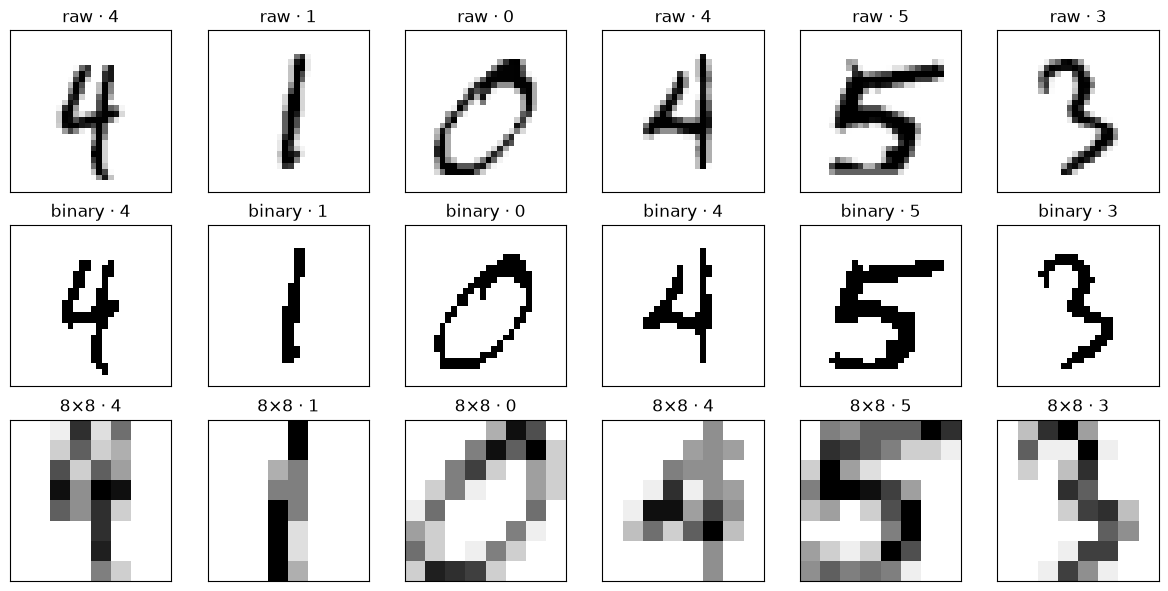

In [3]:
def show_samples(indices):
    fig, axes = plt.subplots(3, len(indices), figsize=(2 * len(indices), 6))
    for column, index in enumerate(indices):
        axes[0, column].imshow(raw_train_images[index], cmap='gray_r', vmin=0, vmax=255)
        axes[0, column].set_title(f'raw · {y_train[index]}')
        threshold = max(1.0, float(raw_train_images[index].max()) * 0.5)
        binary = np.where(raw_train_images[index] >= threshold, 255, 0)
        axes[1, column].imshow(binary, cmap='gray_r', vmin=0, vmax=255)
        axes[1, column].set_title(f'binary · {y_train[index]}')
        axes[2, column].imshow(X_train_images_8x8[index], cmap='gray_r', vmin=0, vmax=16)
        axes[2, column].set_title(f'8×8 · {y_train[index]}')
        for row in range(3):
            axes[row, column].set_xticks([])
            axes[row, column].set_yticks([])
    plt.tight_layout()

sample_indices = np.random.default_rng(RANDOM_SEED).choice(len(y_train), 6, replace=False)
show_samples(sample_indices)

## Xuất thư mục dataset

Thư mục này chứa ảnh raw 28×28, ảnh đã normalize 8×8 và các JSON mô tả dataset/split.

In [4]:
DATASET_DIR.mkdir(parents=True, exist_ok=True)
np.savez_compressed(
    RAW_PATH,
    X_train_images=raw_train_images.astype(np.uint8),
    y_train=y_train.astype(np.int64),
    X_test_images=raw_test_images.astype(np.uint8),
    y_test=y_test.astype(np.int64),
)
np.savez_compressed(
    NORMALIZED_PATH,
    X_train_pixels=X_train_images_8x8.astype(np.float32),
    y_train=y_train.astype(np.int64),
    X_test_pixels=X_test_images_8x8.astype(np.float32),
    y_test=y_test.astype(np.int64),
)
train_indices, validation_indices = train_test_split(
    np.arange(len(y_train)), test_size=0.2, stratify=y_train, random_state=RANDOM_SEED
)
SPLIT_PATH.write_text(json.dumps({
    'random_seed': RANDOM_SEED,
    'fit_indices': train_indices.astype(int).tolist(),
    'validation_indices': validation_indices.astype(int).tolist(),
    'test_indices': np.arange(len(y_test)).astype(int).tolist(),
}, indent=2), encoding='utf-8')
META_PATH.write_text(json.dumps({
    'name': 'MNIST handwritten digits',
    'source_url': 'https://yann.lecun.com/exdb/mnist/',
    'raw_file': RAW_PATH.name,
    'normalized_file': NORMALIZED_PATH.name,
    'raw_shape': {'train': list(raw_train_images.shape), 'test': list(raw_test_images.shape)},
    'normalized_shape': {'train': list(X_train_images_8x8.shape), 'test': list(X_test_images_8x8.shape)},
    'pixel_range': [0, 16],
    'pipeline': ['threshold and binarize black/white', 'largest connected component', 'crop', 'center in square canvas', 'area-average resize 8x8', 'scale 0..16'],
}, indent=2), encoding='utf-8')
print('Wrote directory:', DATASET_DIR)
for path in (RAW_PATH, NORMALIZED_PATH, META_PATH, SPLIT_PATH):
    print(f'  {path.name}: {path.stat().st_size / 1024 / 1024:.1f} MB')

Wrote directory: /Users/nguyenkz/Documents/code/hoc/CS2207.26.1.CH.02/gk/web/backend/artifacts/mnist_dataset
  mnist_raw.npz: 11.0 MB
  mnist_normalized.npz: 2.6 MB
  dataset_meta.json: 0.0 MB
  split.json: 0.7 MB
